In [2]:
# Обработка пропущенных значений
# Анализ выбросов
# Создание новых признаков
# Оценить важность признаков
# Удалить лишние признаки

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

import hydra
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from catboost import CatBoostRegressor
from hydra import compose, initialize
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

plt.style.use("fivethirtyeight")
%matplotlib inline

def get_config(config_path = './config', config_name = 'config.yaml'):
    hydra.core.global_hydra.GlobalHydra.instance().clear()

    with initialize(version_base=None, config_path=config_path):
        cfg = compose(config_name=config_name)
    return cfg

cfg = get_config()

In [2]:
cfg.model.nn_model.loss_function

{'_target_': 'torch.nn.MSELoss'}

In [4]:
train_data = pd.read_csv(cfg.data.train_path)
train_data.set_index('Id', inplace=True)

test_data = pd.read_csv(cfg.data.test_path)
test_data.set_index('Id', inplace=True)

df = train_data.copy(deep=True)

na_cols = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', \
'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', \
'GarageType', 'GarageFinish', 'GarageQual', \
'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']

df[na_cols] = df[na_cols].fillna('NA')

In [5]:
from preprocessing import FeatureEngineer

# Создаем и обучаем
fe = FeatureEngineer()
fe.fit(df)

# Применяем преобразование
df_transformed = fe.transform(df)

print("До преобразования:")
print(df)
print("\nПосле преобразования:")
print(df_transformed)
print(f"\nКолонки: {df_transformed.columns.tolist()}")

До преобразования:
      MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
Id                                                                      
1             60       RL         65.0     8450   Pave    NA      Reg   
2             20       RL         80.0     9600   Pave    NA      Reg   
3             60       RL         68.0    11250   Pave    NA      IR1   
4             70       RL         60.0     9550   Pave    NA      IR1   
5             60       RL         84.0    14260   Pave    NA      IR1   
...          ...      ...          ...      ...    ...   ...      ...   
1456          60       RL         62.0     7917   Pave    NA      Reg   
1457          20       RL         85.0    13175   Pave    NA      Reg   
1458          70       RL         66.0     9042   Pave    NA      Reg   
1459          20       RL         68.0     9717   Pave    NA      Reg   
1460          20       RL         75.0     9937   Pave    NA      Reg   

     LandContour Utilities LotC

In [6]:
"""
Alley           : Тип проулка сзади (Grvl, Pave, NA=нет)
Bedroom         : Спален над землей (без подвала)
BldgType        : Тип здания (1Fam, 2FmCon, Duplx, TwnhsE, TwnhsI)
BsmtCond        : Состояние подвала (Ex, Gd, TA, Fa, Po, NA=нет)
BsmtExposure    : Освещение/выход из подвала (Gd, Av, Mn, No, NA=нет)
BsmtFinSF1      : Площадь отделки подвала (тип 1) в кв.футах
BsmtFinSF2      : Площадь отделки подвала (тип 2) в кв.футах
BsmtFinType1    : Рейтинг отделки подвала (GLQ, ALQ, BLQ, Rec, LwQ, Unf, NA=нет)
BsmtFinType2    : Рейтинг отделки подвала (вторая зона) (GLQ, ALQ, BLQ, Rec, LwQ, Unf, NA=нет)
BsmtFullBath    : Полных ванных в подвале
BsmtHalfBath    : Полуванных в подвале
BsmtQual        : Высота потолков в подвале (Ex, Gd, TA, Fa, Po, NA=нет)
BsmtUnfSF       : Неотделанная площадь подвала (кв.футы)
CentralAir      : Центральный кондиционер (N, Y)
Condition1      : Близость к объектам (Artery, Feedr, Norm, RRNn, RRAn, PosN, PosA)
Condition2      : Второй объект рядом (аналогично Condition1)
Electrical      : Тип проводки (SBrkr, FuseA, FuseF, FuseP, Mix)
EnclosedPorch   : Закрытая веранда (кв.футы)
ExterCond       : Состояние внешней отделки (Ex, Gd, TA, Fa, Po)
ExterQual       : Качество внешней отделки (Ex, Gd, TA, Fa, Po)
Exterior1st     : Основная внешняя облицовка
Exterior2nd     : Вторая внешняя облицовка (если есть)
Fence           : Забор (GdPrv, MnPrv, GdWo, MnWw, NA=нет)
FireplaceQu     : Качество камина (Ex, Gd, TA, Fa, Po, NA=нет)
Fireplaces      : Количество каминов
Foundation      : Тип фундамента (BrkTil, CBlock, PConc, Slab, Stone, Wood)
FullBath        : Полных ванных над землей
Functional      : Функциональность (Typ, Min1, Min2, Mod, Maj1, Maj2, Sev, Sal)
GarageArea      : Площадь гаража (кв.футы)
GarageCars      : Вместимость гаража (машиномест)
GarageCond      : Состояние гаража (Ex, Gd, TA, Fa, Po, NA=нет)
GarageFinish    : Отделка внутри гаража (Fin, RFn, Unf, NA=нет)
GarageQual      : Качество гаража (Ex, Gd, TA, Fa, Po, NA=нет)
GarageType      : Тип гаража (2Types, Attchd, Basment, BuiltIn, CarPort, Detchd, NA=нет)
GarageYrBlt     : Год постройки гаража
GrLivArea       : Общая жилая площадь над землей (кв.футы)
HalfBath        : Полуванных над землей
Heating         : Тип отопления (Floor, GasA, GasW, Grav, OthW, Wall)
HeatingQC       : Качество отопления (Ex, Gd, TA, Fa, Po)
HouseStyle      : Стиль (1Story, 1.5Fin, 1.5Unf, 2Story, 2.5Fin, 2.5Unf, SFoyer, SLvl)
Kitchen         : Кухонь над землей
KitchenQual     : Качество кухни (Ex, Gd, TA, Fa, Po)
LandContour     : Рельеф (Lvl, Bnk, HLS, Low)
LandSlope       : Уклон (Gtl, Mod, Sev)
LotArea         : Площадь участка (кв.футы)
LotConfig       : Конфигурация (Inside, Corner, CulDSac, FR2, FR3)
LotFrontage     : Длина фронтальной линии участка вдоль улицы (футы) - ЕСТЬ ПРОПУСКИ
LotShape        : Форма участка (Reg, IR1, IR2, IR3)
LowQualFinSF    : Площадь с низкокачественной отделкой (все этажи)
MSSubClass      : Код типа строения (стиль + эпоха постройки)
MSZoning        : Класс зонирования участка
MasVnrArea      : Площадь каменной облицовки (кв.футы) - ЕСТЬ ПРОПУСКИ
MasVnrType      : Тип каменной облицовки (BrkCmn, BrkFace, CBlock, None, Stone)
MiscFeature     : Редкие объекты (Elev, Gar2, Othr, Shed, TenC, NA=нет)
MiscVal         : Стоимость редких объектов ($)
MoSold          : Месяц продажи (1-12)
Neighborhood    : Район города (25 вариантов)
OpenPorchSF     : Открытая веранда (кв.футы)
OverallCond     : Общее состояние (1-10, где 10=Excellent)
OverallQual     : Общее качество (1-10, где 10=Excellent)
PavedDrive      : Подъездная дорога (Y, P, N)
PoolArea        : Площадь бассейна (кв.футы)
PoolQC          : Качество бассейна (Ex, Gd, TA, Fa, NA=нет)
RoofMatl        : Материал крыши (ClyTile, CompShg, Membran, Metal, Roll, Tar&Grv, WdShake, WdShngl)
RoofStyle       : Форма крыши (Flat, Gable, Gambrel, Hip, Mansard, Shed)
SaleCondition   : Условия продажи (Normal, Abnorml, AdjLand, Alloca, Family, Partial)
SaleType        : Тип сделки (WD, CWD, VWD, New, COD, Con, ConLw, ConLI, ConLD, Oth)
ScreenPorch     : Застекленная веранда (кв.футы)
Street          : Тип дороги у участка (Grvl, Pave)
3SsnPorch       : Трехсезонная веранда (кв.футы)
TotRmsAbvGrd    : Всего комнат над землей (без ванных)
TotalBsmtSF     : Общая площадь подвала (кв.футы)
Utilities       : Коммуникации (AllPub, NoSewr, NoSeWa, ELO)
WoodDeckSF      : Деревянная терраса (кв.футы)
YearBuilt       : Год постройки
YearRemodAdd    : Год последнего ремонта
YrSold          : Год продажи
1stFlrSF        : Площадь 1-го этажа (кв.футы)
2ndFlrSF        : Площадь 2-го этажа (кв.футы)"""

'\nAlley           : Тип проулка сзади (Grvl, Pave, NA=нет)\nBedroom         : Спален над землей (без подвала)\nBldgType        : Тип здания (1Fam, 2FmCon, Duplx, TwnhsE, TwnhsI)\nBsmtCond        : Состояние подвала (Ex, Gd, TA, Fa, Po, NA=нет)\nBsmtExposure    : Освещение/выход из подвала (Gd, Av, Mn, No, NA=нет)\nBsmtFinSF1      : Площадь отделки подвала (тип 1) в кв.футах\nBsmtFinSF2      : Площадь отделки подвала (тип 2) в кв.футах\nBsmtFinType1    : Рейтинг отделки подвала (GLQ, ALQ, BLQ, Rec, LwQ, Unf, NA=нет)\nBsmtFinType2    : Рейтинг отделки подвала (вторая зона) (GLQ, ALQ, BLQ, Rec, LwQ, Unf, NA=нет)\nBsmtFullBath    : Полных ванных в подвале\nBsmtHalfBath    : Полуванных в подвале\nBsmtQual        : Высота потолков в подвале (Ex, Gd, TA, Fa, Po, NA=нет)\nBsmtUnfSF       : Неотделанная площадь подвала (кв.футы)\nCentralAir      : Центральный кондиционер (N, Y)\nCondition1      : Близость к объектам (Artery, Feedr, Norm, RRNn, RRAn, PosN, PosA)\nCondition2      : Второй объект

In [7]:
# Разделим df на два по тику признаков, т.к они будут по-разному обрабатываться
obj_df = df.select_dtypes(include=['object'])
num_df = df.select_dtypes(include=['number'])

assert len(df.columns) == len(obj_df.columns) + len(num_df.columns)

# Длля удобства обработки none значений
nan_num_df = num_df.loc[:, num_df.isna().any()]
nan_obj_df = obj_df.loc[:, obj_df.isna().any()]

print(nan_num_df.info(), '\n\n\n')
print(nan_obj_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LotFrontage  1201 non-null   float64
 1   MasVnrArea   1452 non-null   float64
 2   GarageYrBlt  1379 non-null   float64
dtypes: float64(3)
memory usage: 45.6 KB
None 



<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   MasVnrType  588 non-null    object
 1   Electrical  1459 non-null   object
dtypes: object(2)
memory usage: 34.2+ KB
None


### Numeric Features

In [8]:
num_df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [9]:
num_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 37 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1460 non-null   int64  
 3   OverallQual    1460 non-null   int64  
 4   OverallCond    1460 non-null   int64  
 5   YearBuilt      1460 non-null   int64  
 6   YearRemodAdd   1460 non-null   int64  
 7   MasVnrArea     1452 non-null   float64
 8   BsmtFinSF1     1460 non-null   int64  
 9   BsmtFinSF2     1460 non-null   int64  
 10  BsmtUnfSF      1460 non-null   int64  
 11  TotalBsmtSF    1460 non-null   int64  
 12  1stFlrSF       1460 non-null   int64  
 13  2ndFlrSF       1460 non-null   int64  
 14  LowQualFinSF   1460 non-null   int64  
 15  GrLivArea      1460 non-null   int64  
 16  BsmtFullBath   1460 non-null   int64  
 17  BsmtHalfBath   1460 non-null   int64  
 18  FullBath     

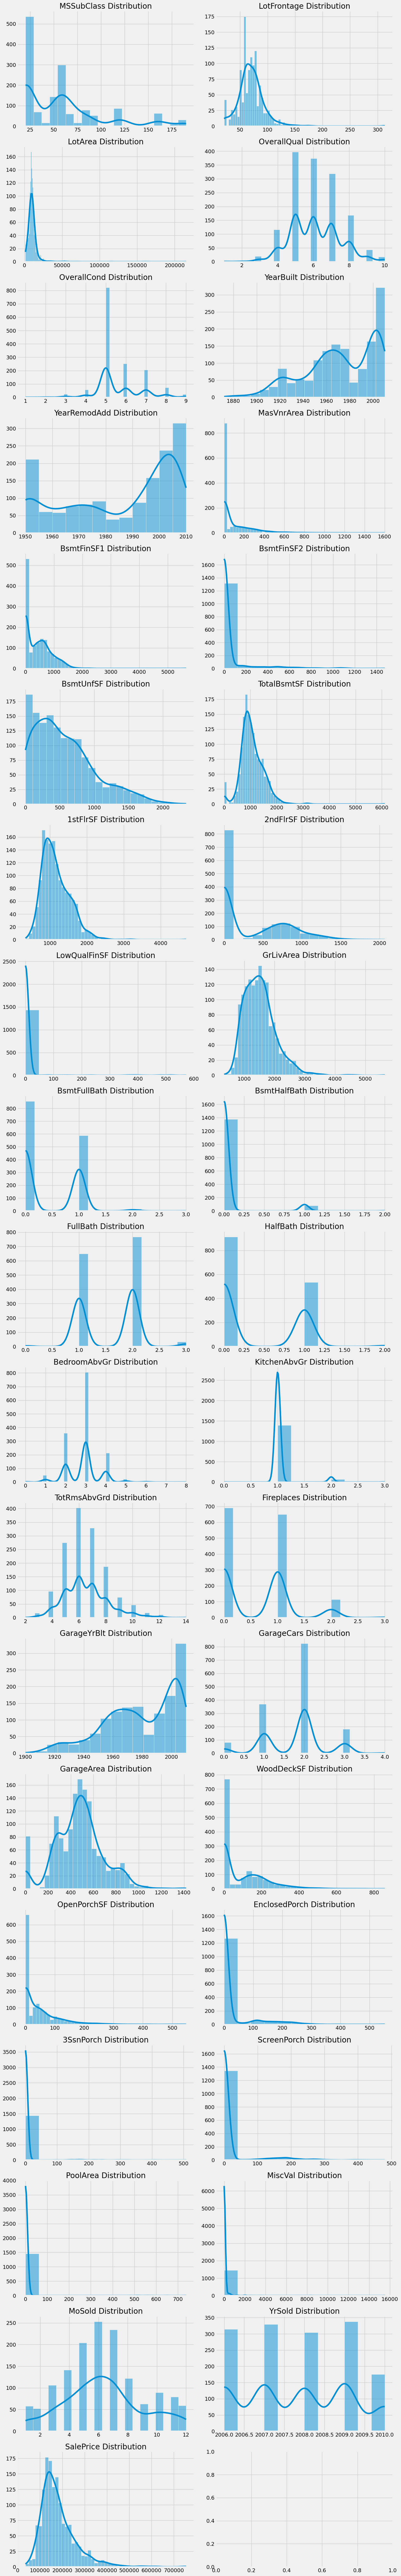

In [10]:
# Строим распределния всех numeric features (В том числе таргета)
n_cols = 2
n_rows = len(num_df.columns) // n_cols + 1

fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))

# Чтобы в цикле можно было передавать все через одну ось 
ax = ax.flatten()

for i, col in enumerate(num_df.columns):
    sns.histplot(data=num_df, x=col, kde=True, ax=ax[i])
    ax[i].set_title(f"{col} Distribution")
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")

plt.tight_layout()
plt.show()

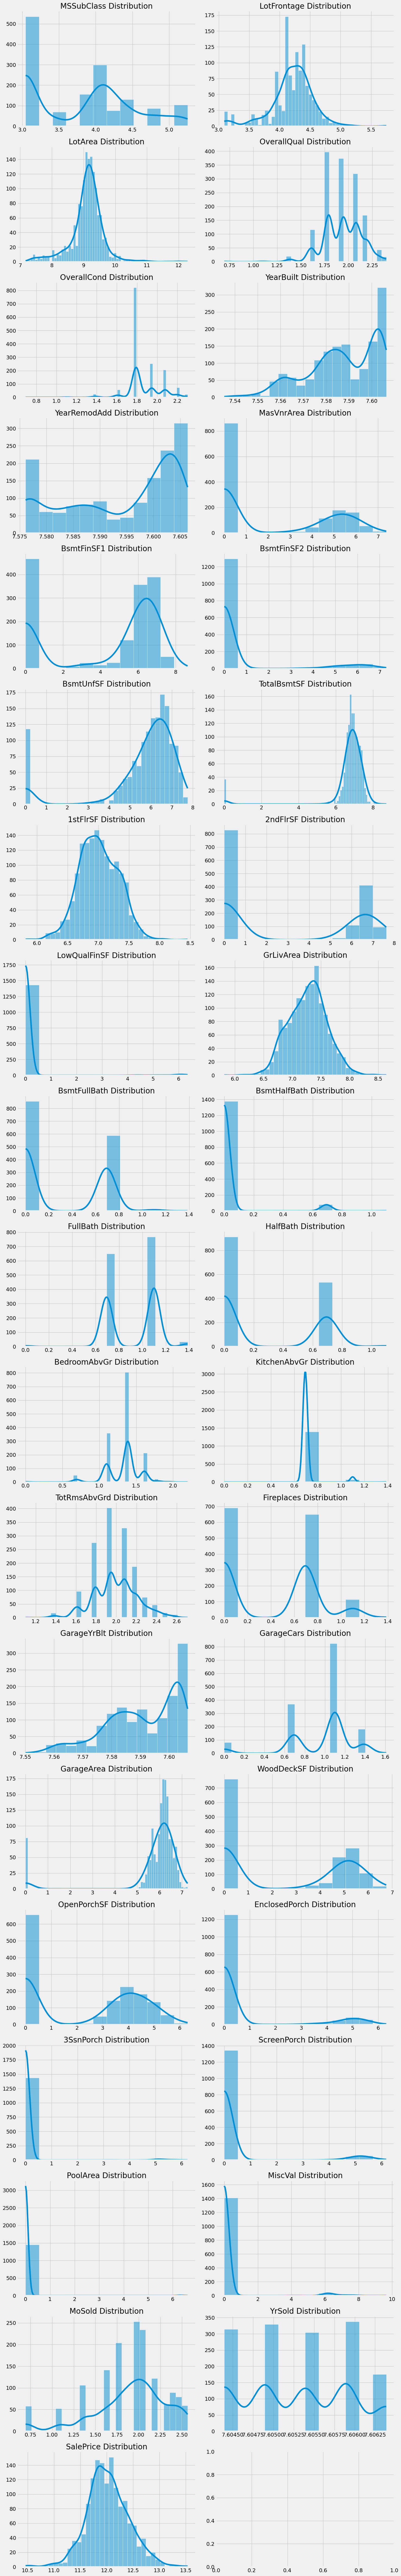

In [11]:
# Строим распределния всех numeric features (В том числе таргета)
n_cols = 2
n_rows = len(num_df.columns) // n_cols + 1

fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))

# Чтобы в цикле можно было передавать все через одну ось 
ax = ax.flatten()

for i, col in enumerate(num_df.columns):
    sns.histplot(data=np.log1p(num_df[col]), kde=True, ax=ax[i])
    ax[i].set_title(f"{col} Distribution")
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")

plt.tight_layout()
plt.show()

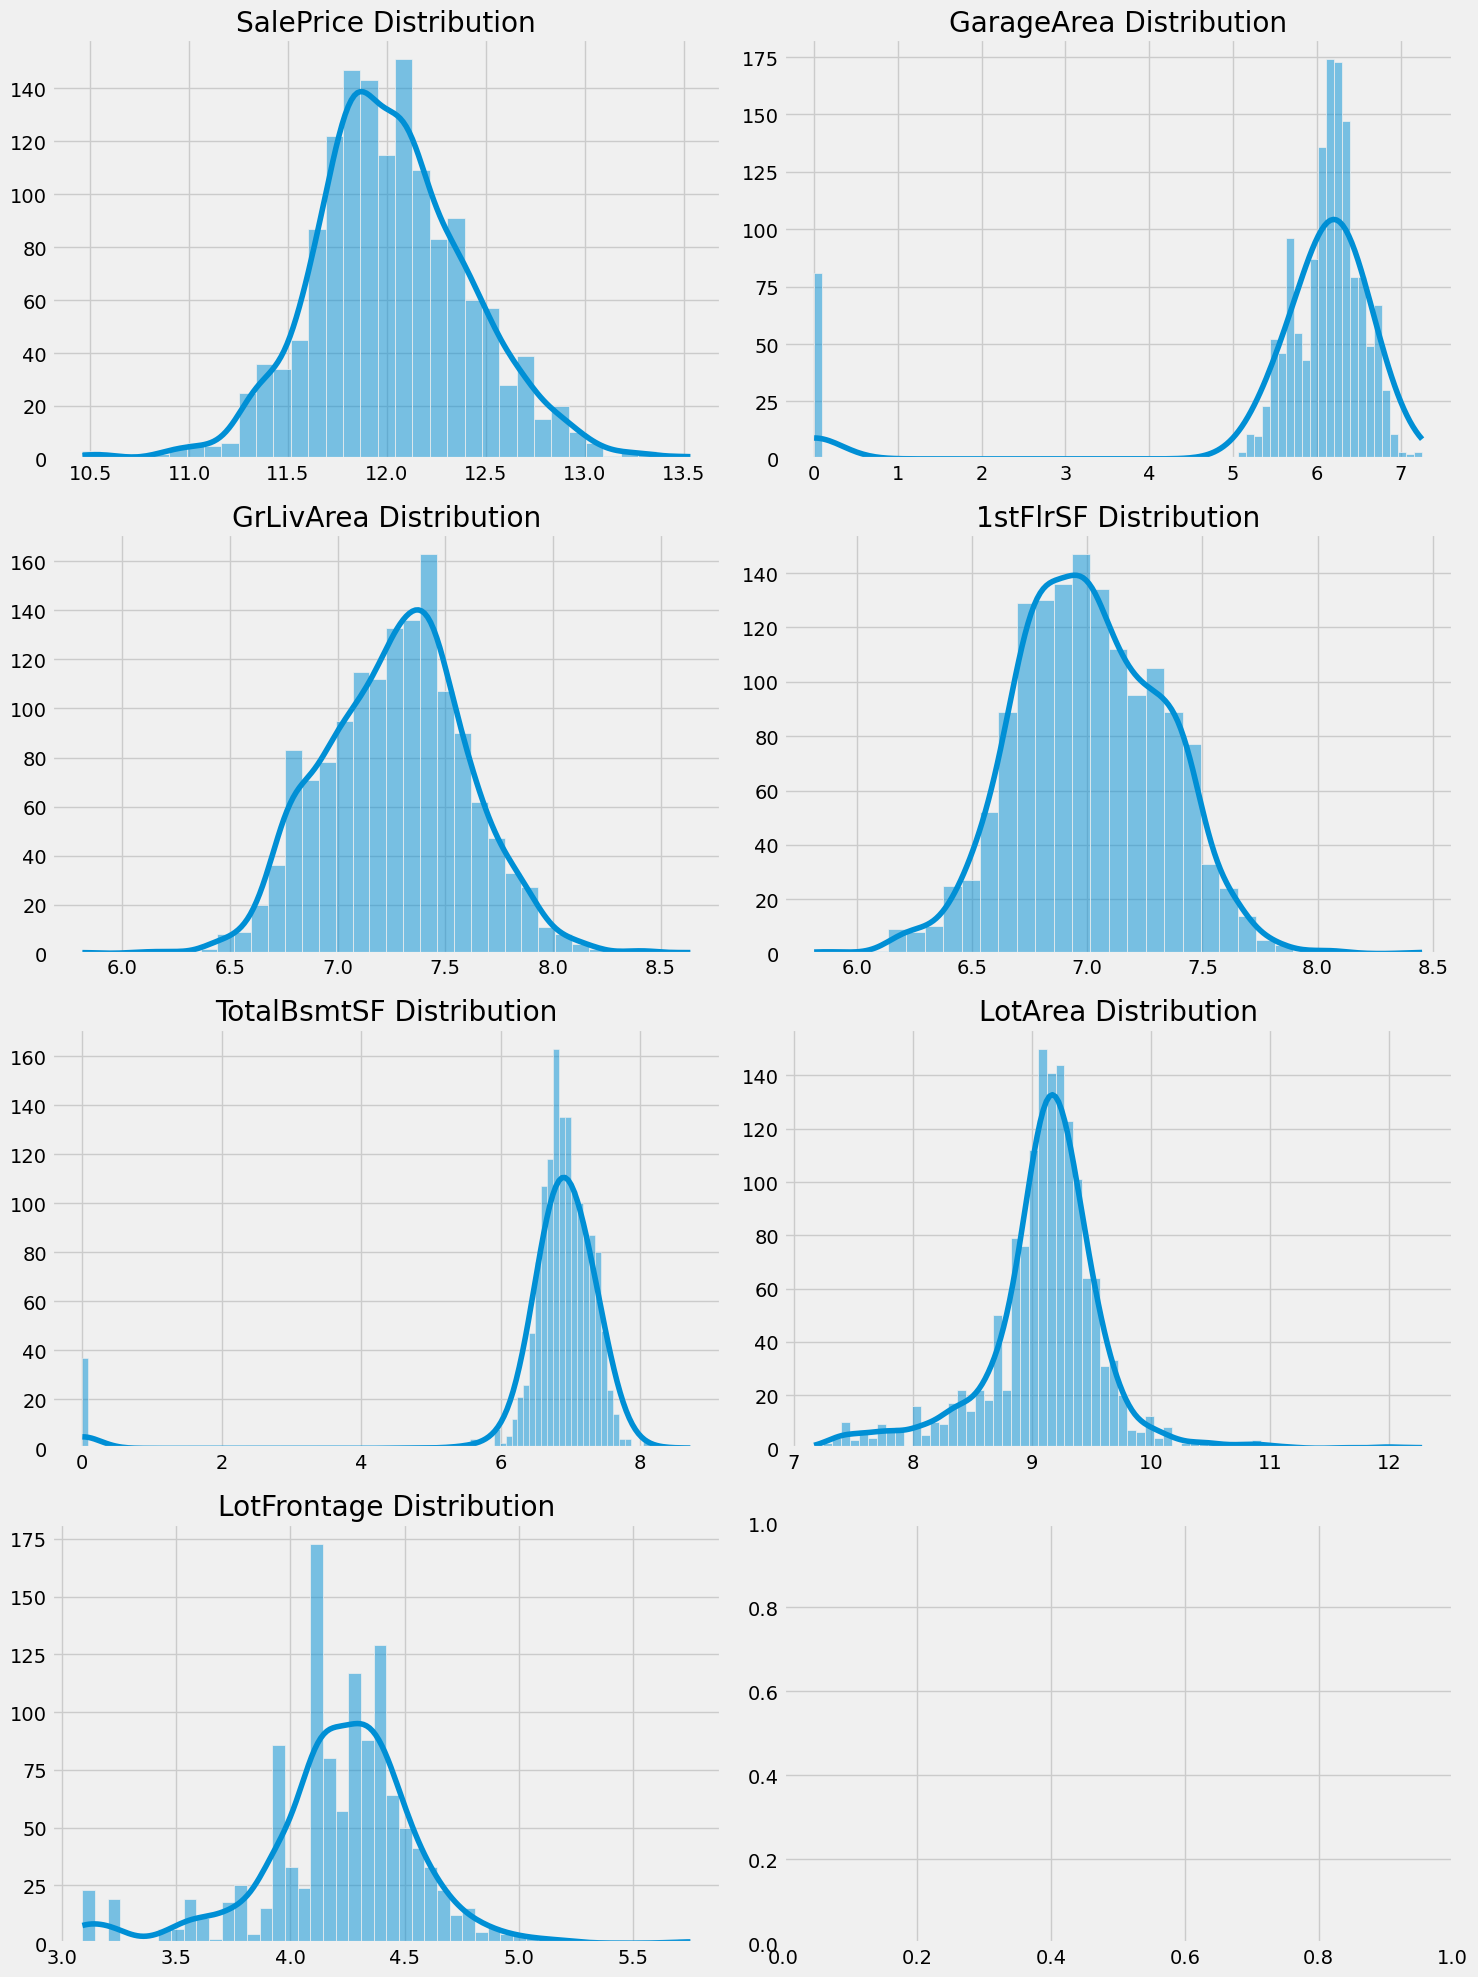

[{'SalePrice': 0.12134661989685333},
 {'GarageArea': -3.482604188040364},
 {'GrLivArea': -0.006140253486287281},
 {'1stFlrSF': 0.08011408968181778},
 {'TotalBsmtSF': -5.1546699835179135},
 {'LotArea': -0.13740448122837784},
 {'LotFrontage': -0.7287278423055492}]

In [12]:
# Строим распределния всех numeric features (В том числе таргета)
n_cols = 2
# n_rows = len(num_df.columns) // n_cols + 1
n_rows = 4

fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))

# Чтобы в цикле можно было передавать все через одну ось 
ax = ax.flatten()

skew_list = []
for i, col in enumerate(['SalePrice', 'GarageArea', 'GrLivArea', '1stFlrSF', 'TotalBsmtSF', 'LotArea', 'LotFrontage']):
    skew_list.append({col: np.log1p(num_df[col]).skew().item()})
    sns.histplot(data=np.log1p(num_df[col]), kde=True, ax=ax[i])
    ax[i].set_title(f"{col} Distribution")
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")

plt.tight_layout()
plt.show()
skew_list

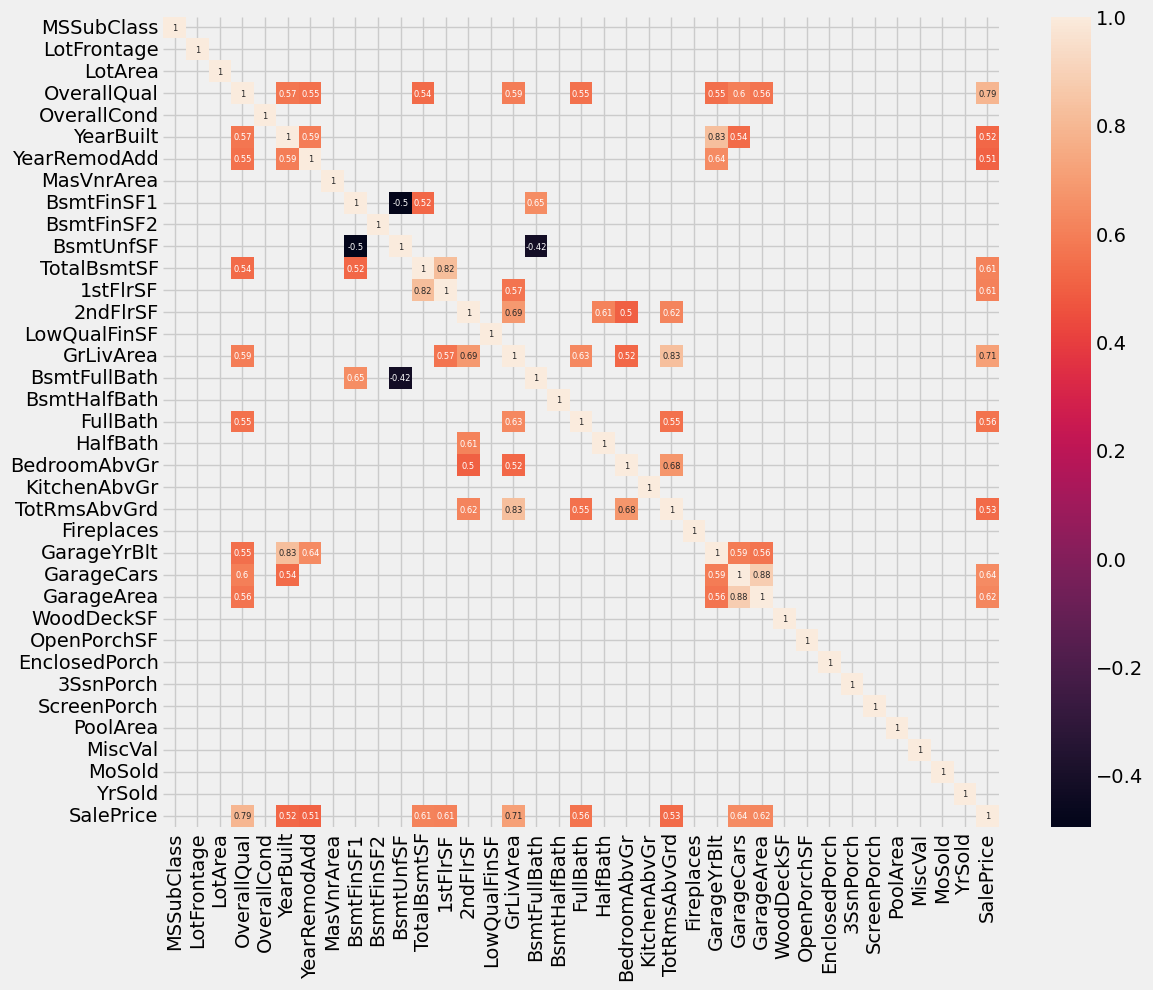

In [13]:
# plt.figure(figsize=(15, 15))
# sns.heatmap(num_df.corr())
# plt.show()

corr = num_df.corr()
plt.figure(figsize=(12, 10))

sns.heatmap(corr[(corr >= 0.5) | (corr <= -0.4)], 
            # cmap='viridis', linewidths=0.1,
            annot=True, annot_kws={"size": 6});

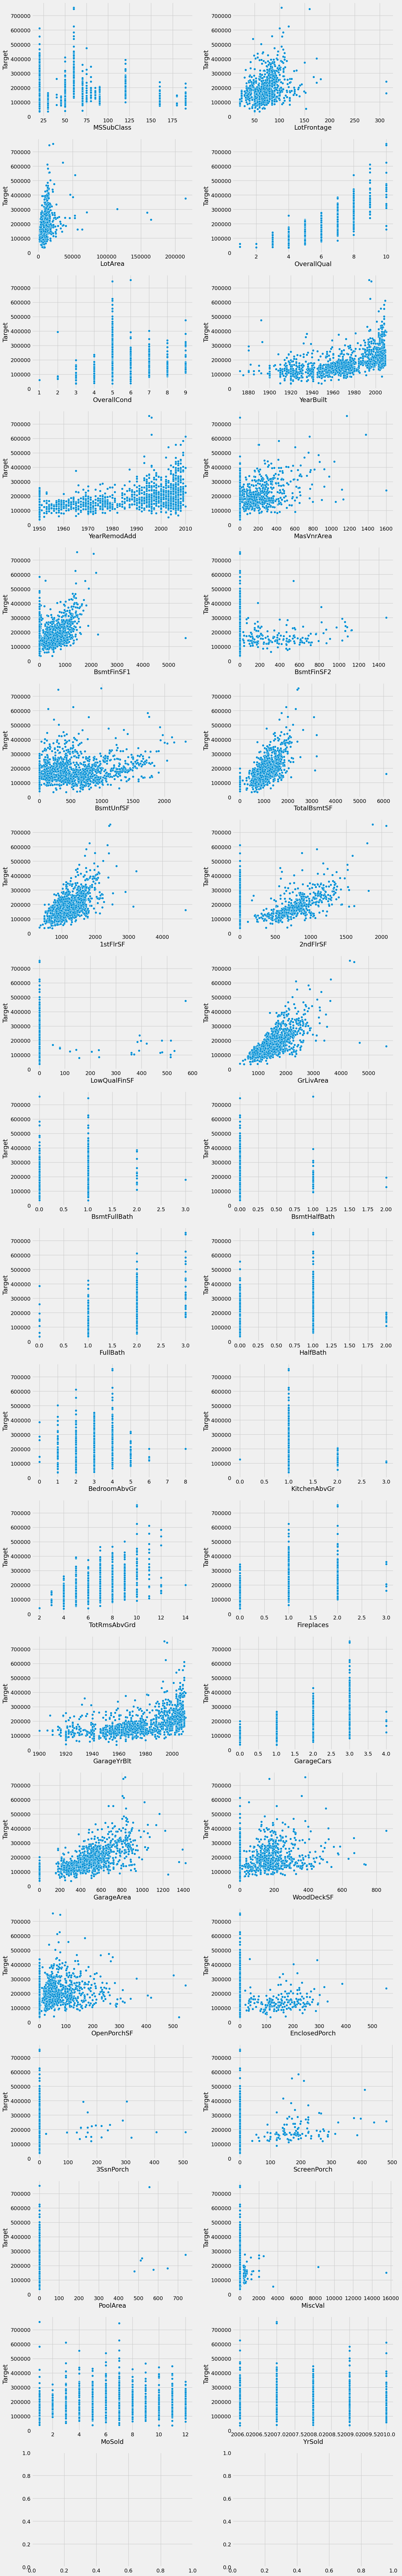

In [14]:
cols = num_df.drop(cfg.target_column, axis=1).columns

n_cols = 2
n_rows = len(cols) // n_cols + 1

fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))

# Чтобы в цикле можно было передавать все через одну ось 
ax = ax.flatten()

for i, col in enumerate(cols):
    sns.scatterplot(data=num_df, x=col, y=cfg.target_column, ax=ax[i])
    ax[i].set_ylabel("Target")

plt.tight_layout()
plt.show()

<Axes: >

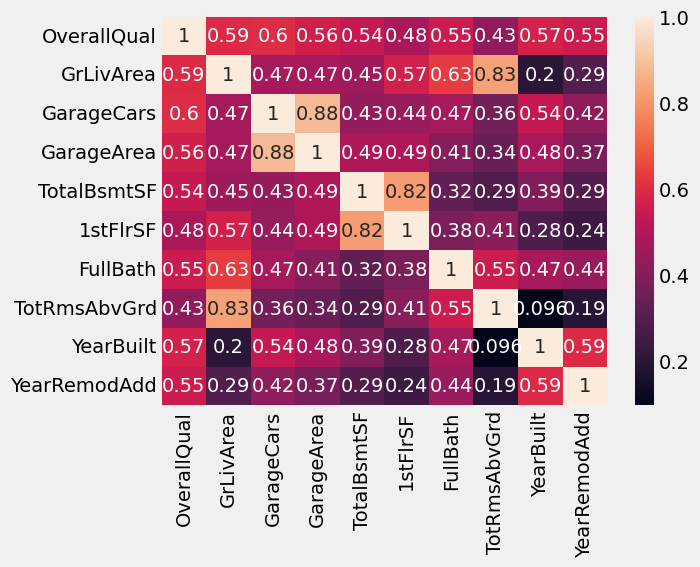

In [15]:
num_df.corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False).head(10)

best_num_features = num_df.corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False).head(10).index.to_list()

sns.heatmap(df[best_num_features].corr(), annot=True)

### Object Features

In [16]:
obj_df.describe()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,...,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460
unique,5,2,3,4,4,2,5,3,25,9,...,7,4,6,6,3,4,5,5,9,6
top,RL,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,NA,NA,NA,WD,Normal
freq,1151,1454,1369,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,1453,1179,1406,1267,1198


In [17]:
obj_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 43 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MSZoning       1460 non-null   object
 1   Street         1460 non-null   object
 2   Alley          1460 non-null   object
 3   LotShape       1460 non-null   object
 4   LandContour    1460 non-null   object
 5   Utilities      1460 non-null   object
 6   LotConfig      1460 non-null   object
 7   LandSlope      1460 non-null   object
 8   Neighborhood   1460 non-null   object
 9   Condition1     1460 non-null   object
 10  Condition2     1460 non-null   object
 11  BldgType       1460 non-null   object
 12  HouseStyle     1460 non-null   object
 13  RoofStyle      1460 non-null   object
 14  RoofMatl       1460 non-null   object
 15  Exterior1st    1460 non-null   object
 16  Exterior2nd    1460 non-null   object
 17  MasVnrType     588 non-null    object
 18  ExterQual      1460 non-null   ob

In [18]:
col_to_val_counts = {}
for col in obj_df.columns:
    col_to_val_counts[col] = obj_df[col].value_counts().to_dict()
    
col_to_val_counts

{'MSZoning': {'RL': 1151, 'RM': 218, 'FV': 65, 'RH': 16, 'C (all)': 10},
 'Street': {'Pave': 1454, 'Grvl': 6},
 'Alley': {'NA': 1369, 'Grvl': 50, 'Pave': 41},
 'LotShape': {'Reg': 925, 'IR1': 484, 'IR2': 41, 'IR3': 10},
 'LandContour': {'Lvl': 1311, 'Bnk': 63, 'HLS': 50, 'Low': 36},
 'Utilities': {'AllPub': 1459, 'NoSeWa': 1},
 'LotConfig': {'Inside': 1052,
  'Corner': 263,
  'CulDSac': 94,
  'FR2': 47,
  'FR3': 4},
 'LandSlope': {'Gtl': 1382, 'Mod': 65, 'Sev': 13},
 'Neighborhood': {'NAmes': 225,
  'CollgCr': 150,
  'OldTown': 113,
  'Edwards': 100,
  'Somerst': 86,
  'Gilbert': 79,
  'NridgHt': 77,
  'Sawyer': 74,
  'NWAmes': 73,
  'SawyerW': 59,
  'BrkSide': 58,
  'Crawfor': 51,
  'Mitchel': 49,
  'NoRidge': 41,
  'Timber': 38,
  'IDOTRR': 37,
  'ClearCr': 28,
  'SWISU': 25,
  'StoneBr': 25,
  'Blmngtn': 17,
  'MeadowV': 17,
  'BrDale': 16,
  'Veenker': 11,
  'NPkVill': 9,
  'Blueste': 2},
 'Condition1': {'Norm': 1260,
  'Feedr': 81,
  'Artery': 48,
  'RRAn': 26,
  'PosN': 19,
  'RR

In [19]:

for col in obj_df.columns:
    a = list(obj_df[col].value_counts().keys())
    print(f"{len(a)}\t{a}")


5	['RL', 'RM', 'FV', 'RH', 'C (all)']
2	['Pave', 'Grvl']
3	['NA', 'Grvl', 'Pave']
4	['Reg', 'IR1', 'IR2', 'IR3']
4	['Lvl', 'Bnk', 'HLS', 'Low']
2	['AllPub', 'NoSeWa']
5	['Inside', 'Corner', 'CulDSac', 'FR2', 'FR3']
3	['Gtl', 'Mod', 'Sev']
25	['NAmes', 'CollgCr', 'OldTown', 'Edwards', 'Somerst', 'Gilbert', 'NridgHt', 'Sawyer', 'NWAmes', 'SawyerW', 'BrkSide', 'Crawfor', 'Mitchel', 'NoRidge', 'Timber', 'IDOTRR', 'ClearCr', 'SWISU', 'StoneBr', 'Blmngtn', 'MeadowV', 'BrDale', 'Veenker', 'NPkVill', 'Blueste']
9	['Norm', 'Feedr', 'Artery', 'RRAn', 'PosN', 'RRAe', 'PosA', 'RRNn', 'RRNe']
8	['Norm', 'Feedr', 'Artery', 'RRNn', 'PosN', 'PosA', 'RRAn', 'RRAe']
5	['1Fam', 'TwnhsE', 'Duplex', 'Twnhs', '2fmCon']
8	['1Story', '2Story', '1.5Fin', 'SLvl', 'SFoyer', '1.5Unf', '2.5Unf', '2.5Fin']
6	['Gable', 'Hip', 'Flat', 'Gambrel', 'Mansard', 'Shed']
8	['CompShg', 'Tar&Grv', 'WdShngl', 'WdShake', 'Metal', 'Membran', 'Roll', 'ClyTile']
15	['VinylSd', 'HdBoard', 'MetalSd', 'Wd Sdng', 'Plywood', 'CemntBd',



In [20]:
n_cols = 2
n_rows = len(obj_df.columns) // n_cols + 1

fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))

# Чтобы в цикле можно было передавать все через одну ось 
ax = ax.flatten()

for i, col in enumerate(obj_df.columns):
    sns.countplot(data=obj_df, x=col, ax=ax[i])
    ax[i].set_title(f"{col} Countplot")
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")

plt.tight_layout()
plt.show()

### Missing Values

In [21]:
# Признаки у которых графа NA не является пропуском
# ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', \
# 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', \
# 'GarageType', 'GarageFinish', 'GarageQual', \
# 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']

# df[na_cols].info()
# Признаки у которых есть пропуски и их надо чем-то заполнить (1, 7, 16, 17, 18)

In [22]:
df.loc[(df['LotFrontage'].isna()), ['LotFrontage', 'LotArea', 'LotShape']]

df['Electrical'].value_counts()
el_mode = df['Electrical'].mode()[0]


garage_cols = ['GarageYrBlt', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'GarageArea', 'GarageCars']
df[df['GarageYrBlt'].isna()][garage_cols]

a = df[(df['MasVnrArea'] >= 0.0) & (df['MasVnrType'].isna())][['MasVnrType', 'MasVnrArea']].shape[0]
b = df[(df['MasVnrArea'].isna()) & (df['MasVnrType'].isna())][['MasVnrType', 'MasVnrArea']].shape[0]
assert a + b + 588 == 1460

shape_to_area = df.groupby(by='LotShape')['LotArea'].median().items()
shape_to_frontage = {k: np.sqrt(v).item() for k, v in shape_to_area}

df['MasVnrType'].value_counts()
mas_mode = df['MasVnrType'].mode()[0]


In [23]:
df.loc[df['Electrical'].isna(), ['Electrical']] = el_mode

df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

for k, v in shape_to_frontage.items():
    df.loc[(df['LotFrontage'].isna()) & (df['LotShape'] == k), 'LotFrontage'] = v

df.loc[(df['MasVnrArea'] > 0.0) & (df['MasVnrType'].isna()), 'MasVnrType'] = mas_mode
df['MasVnrType'] = df['MasVnrType'].fillna('None')
df['MasVnrArea'] = df['MasVnrArea'].fillna(0.0)

### Outliers

In [24]:
def look_for_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    return df[mask][[col]]

for col in num_df.columns:
    print(f"{col}: {look_for_outliers(num_df, col).shape[0]}")

MSSubClass: 103
LotFrontage: 88
LotArea: 69
OverallQual: 2
OverallCond: 125
YearBuilt: 7
YearRemodAdd: 0
MasVnrArea: 96
BsmtFinSF1: 7
BsmtFinSF2: 167
BsmtUnfSF: 29
TotalBsmtSF: 61
1stFlrSF: 20
2ndFlrSF: 2
LowQualFinSF: 26
GrLivArea: 31
BsmtFullBath: 1
BsmtHalfBath: 82
FullBath: 0
HalfBath: 0
BedroomAbvGr: 35
KitchenAbvGr: 68
TotRmsAbvGrd: 30
Fireplaces: 5
GarageYrBlt: 0
GarageCars: 5
GarageArea: 21
WoodDeckSF: 32
OpenPorchSF: 77
EnclosedPorch: 208
3SsnPorch: 24
ScreenPorch: 116
PoolArea: 7
MiscVal: 52
MoSold: 0
YrSold: 0
SalePrice: 61


### Feature Importance

In [25]:
df['SalePrice'] = np.log1p(df['SalePrice'])

In [26]:
# df1 = pd.concat([num_df, obj_df])

X_train, X_test, y_train, y_test = train_test_split(
        df.drop(columns=[cfg.target_column]), 
        df[cfg.target_column], 
        test_size=0.2, 
        random_state=42
        )

model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=4,
    l2_leaf_reg=5,
    cat_features=obj_df.columns.to_list(),
    bootstrap_type='Bernoulli',     
    subsample=0.7,                  
    rsm=0.7,                        
    random_seed=42,
    verbose=False
)

model.fit(X_train, y_train)

print("Модель успешно обучена!")

preds = model.predict(X_test)
test_acc = root_mean_squared_error(y_test, preds)
print(test_acc)

Модель успешно обучена!
0.14303461469435838


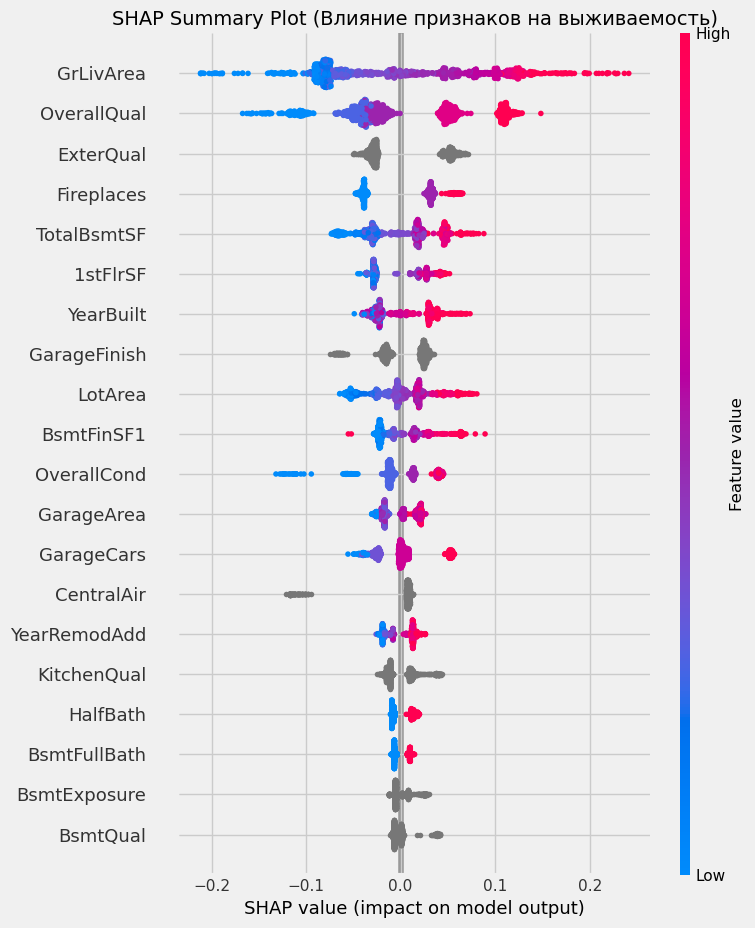

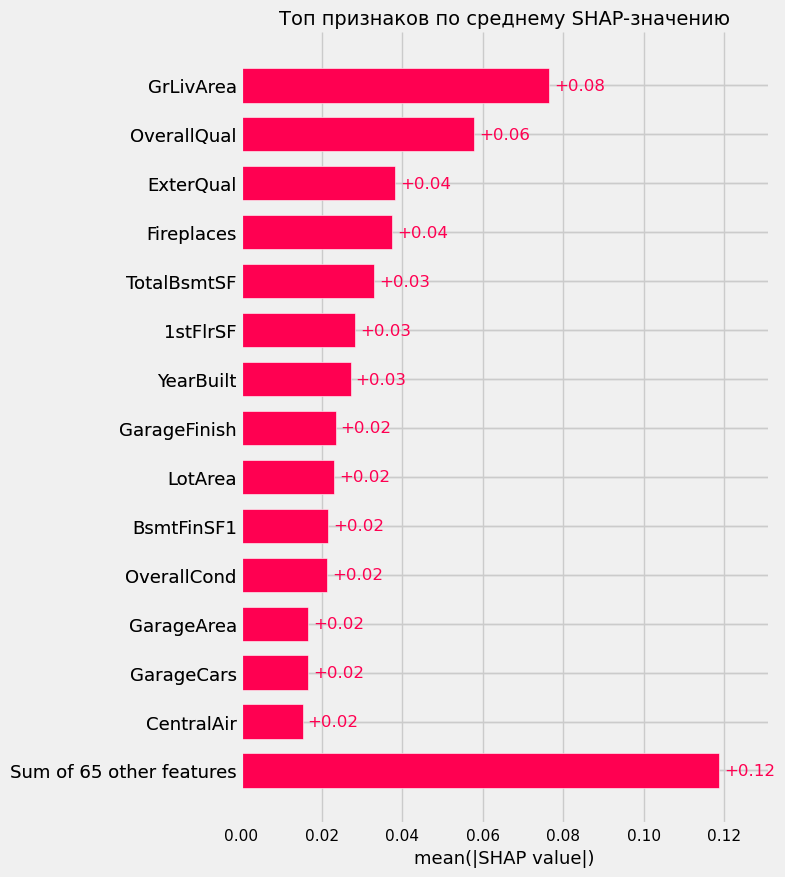

In [27]:
explainer = shap.TreeExplainer(model)

shap_vals = explainer(X_train)

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_vals, X_train, plot_type="dot", show=False
)
plt.title("SHAP Summary Plot (Влияние признаков на выживаемость)", fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.plots.bar(shap_vals, max_display=15, show=False)
plt.title("Топ признаков по среднему SHAP-значению", fontsize=14)
plt.tight_layout()
plt.show()

### Encoding, Scaling

In [28]:
ordinal_features = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 
    'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 
    'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 
    'PoolQC', 'Fence', 'LandSlope', 'LotShape', 'Functional'
]

ordinal_df = df[ordinal_features]


# Порядок от худшего к лучшему
standard_qual = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
standard_qual_with_na = ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex']

# Словарь упорядоченных категорий для каждого признака
ordinal_categories = {
    'ExterQual': standard_qual,
    'ExterCond': standard_qual,
    'HeatingQC': standard_qual,
    'KitchenQual': standard_qual,
    
    'BsmtQual': standard_qual_with_na,
    'BsmtCond': standard_qual_with_na,
    'FireplaceQu': standard_qual_with_na,
    'GarageQual': standard_qual_with_na,
    'GarageCond': standard_qual_with_na,
    'PoolQC': standard_qual_with_na,
    
    # Освещенность подвала (NA - нет подвала, No - окон нет, Mn - минимум, Av - средне, Gd - отлично)
    'BsmtExposure': ['NA', 'No', 'Mn', 'Av', 'Gd'],
    
    # Рейтинг отделки подвала (Unf - без отделки, LwQ...GLQ - хорошее качество)
    'BsmtFinType1': ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'BsmtFinType2': ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    
    # Внутренняя отделка гаража (NA - нет гаража, Unf - без отделки, RFn - частично, Fin - чистовая)
    'GarageFinish': ['NA', 'Unf', 'RFn', 'Fin'],
    
    # Забор (NA - нет, MnWw - сетка/минимум, GdWo - хорошее дерево, MnPrv - средняя приватность, GdPrv - полная приватность)
    'Fence': ['NA', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
    
    # Уклон участка (Sev - крутой, Mod - средний, Gtl - пологий/ровный, что лучше всего для стройки)
    'LandSlope': ['Sev', 'Mod', 'Gtl'],
    
    # Форма участка (IR3 - сильно неправильная, IR2 - неправильная, IR1 - слегка неправильная, Reg - идеальный прямоугольник)
    'LotShape': ['IR3', 'IR2', 'IR1', 'Reg'],
    
    # Функциональность дома (Sal - только на снос, Sev... Min1 - мелкие повреждения, Typ - исправен)
    'Functional': ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']
}

# Превращаем словарь в список списков, который требует OrdinalEncoder
# Порядок списков внутри должен строго соответствовать порядку колонок в X[features]
ordered_features_list = list(ordinal_categories.keys())
categories_list = [ordinal_categories[col] for col in ordered_features_list]

In [29]:
other_cols = []
for col in df.columns:
    if col not in ordinal_features:
        other_cols.append(col)

cat_features = df[other_cols].select_dtypes('object').columns

num_features = df[other_cols].select_dtypes('number').drop('SalePrice', axis=1).columns

assert len(df.columns) - 1  == len(ordinal_features) + len(cat_features) + len(num_features)

In [30]:
quant_cols = []
ohe_cols = []

for col in cat_features:
    a = list(df[col].value_counts().keys())
    if len(a) >= 10:
        quant_cols.append(col)
    else:
        ohe_cols.append(col)

In [35]:
from category_encoders import QuantileEncoder
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler 
from sklearn.compose import ColumnTransformer

encoder = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(
        categories=categories_list, 
        handle_unknown='use_encoded_value', 
        unknown_value=-1
    ), ordinal_features),
    ('quantile', QuantileEncoder(
        m=1.0,          # Сглаживание
        quantile=0.5,   # 0.5 означает кодирование по медиане
    ), quant_cols),
    ('ohe', OneHotEncoder(
        drop='first',
        handle_unknown='ignore',
        sparse_output=False
    ), ohe_cols),
    ('num', StandardScaler(), num_features)
], remainder='passthrough')


In [34]:
print(f"ohe_cols: {ohe_cols}\nordinal_cols: {ordinal_features}\nqunatile_cols: {quant_cols}")

ohe_cols: ['MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities', 'LotConfig', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'PavedDrive', 'MiscFeature', 'SaleType', 'SaleCondition']
ordinal_cols: ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'LandSlope', 'LotShape', 'Functional']
qunatile_cols: ['Neighborhood', 'Exterior1st', 'Exterior2nd']
